Please upload the 'edtech_churn_dataset_20000.csv' file.


Saving edtech_churn_dataset_20000.csv to edtech_churn_dataset_20000 (2).csv
User uploaded file "edtech_churn_dataset_20000 (2).csv" with length 1800612 bytes
Loaded dataset: 20000 rows, 24 columns

--- Data types and nulls ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       20000 non-null  int64  
 1   age_group                     20000 non-null  object 
 2   country                       20000 non-null  object 
 3   subscription_type             20000 non-null  object 
 4   signup_source                 20000 non-null  object 
 5   total_courses_enrolled        20000 non-null  int64  
 6   total_courses_completed       20000 non-null  int64  
 7   avg_video_watch_time_per_day  20000 non-null  float64
 8   days_since_last_login         20000 non-null  int64  
 9   assessment

/tmp/ipython-input-2525159050.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_sub = df.groupby('subscription_type')['churn'].mean().reset_index()


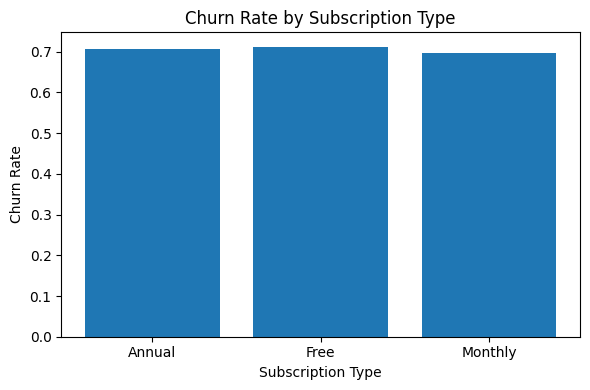

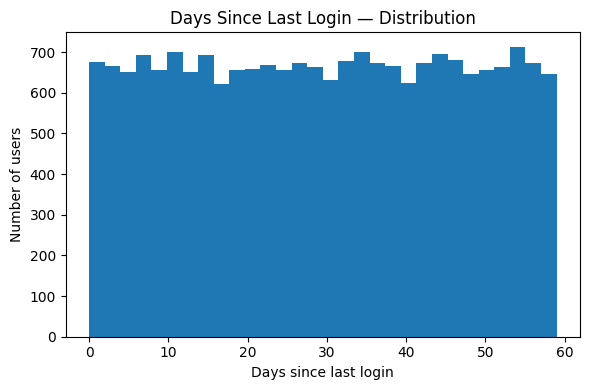

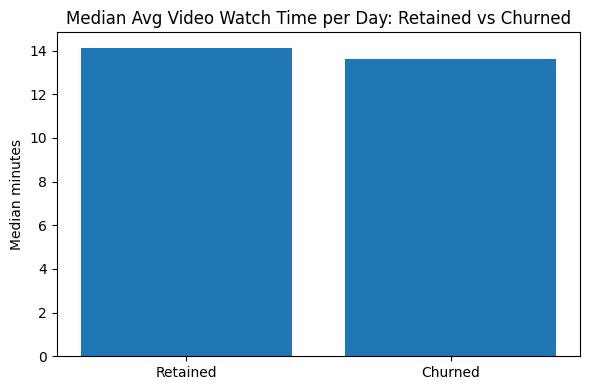

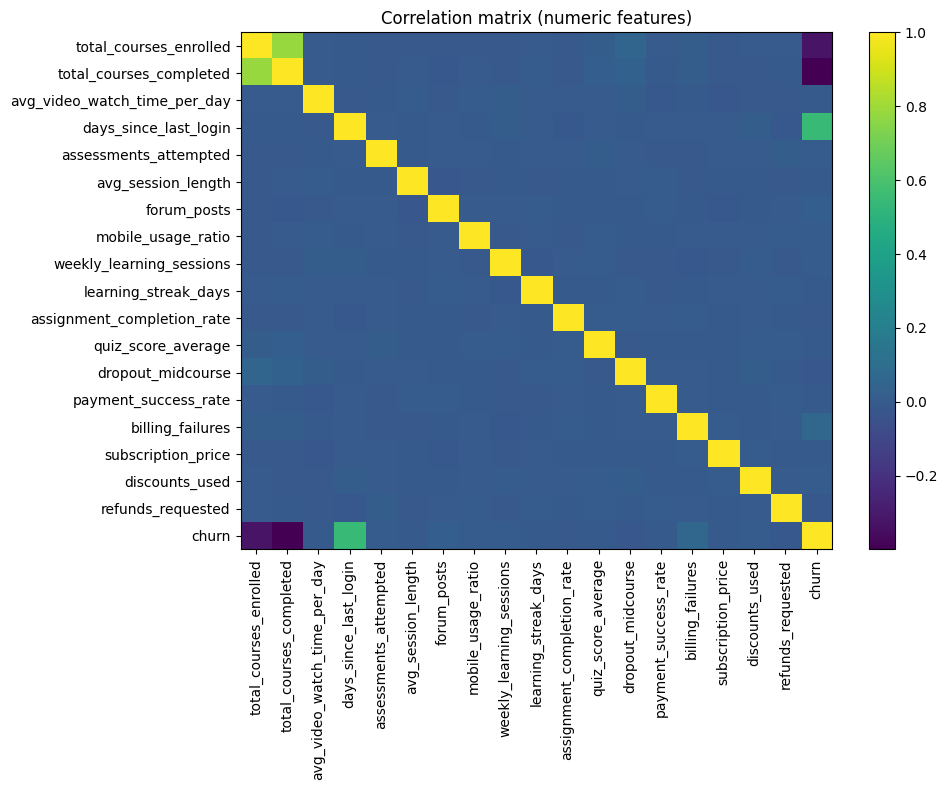


Model-ready dataframe shape: (20000, 37)

Logistic Regression ROC-AUC: 0.9798658982617069
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1476
           1       0.95      0.96      0.95      3524

    accuracy                           0.93      5000
   macro avg       0.92      0.91      0.92      5000
weighted avg       0.93      0.93      0.93      5000


Random Forest ROC-AUC: 0.9999999999999999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1476
           1       1.00      1.00      1.00      3524

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000


Excel file created: edtech_churn_predictions.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# edtech_churn_analysis.py
# Self-contained script: load synthetic Coursera-like dataset, clean, EDA, feature engineering, modeling.
# Requirements: pandas, numpy, matplotlib, scikit-learn, joblib
# Run in Jupyter or regular Python (plots require an interactive backend in normal Python).

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import joblib
from google.colab import files

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# === CONFIG ===
# DATA_PATH = Path("C:/Users/Gapat/Downloads/edtech_churn_dataset_20000.csv") # Original hardcoded path
SAVE_DIR = Path("artifacts")
SAVE_DIR.mkdir(exist_ok=True)

# === LOAD DATA ===
print("Please upload the 'edtech_churn_dataset_20000.csv' file.")
uploaded = files.upload()

# Get the name of the first uploaded file
if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    print(f'User uploaded file "{uploaded_filename}" with length {len(uploaded[uploaded_filename])} bytes')
else:
    raise FileNotFoundError("No file was uploaded.")

df = pd.read_csv(uploaded_filename)
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")

# === QUICK OVERVIEW ===
print("\n--- Data types and nulls ---")
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nChurn distribution (proportion):")
print(df['churn'].value_counts(normalize=True))

# === DATA CLEANING / SANITY CHECKS ===
cat_cols = ['age_group', 'country', 'subscription_type', 'signup_source']
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype('category')

if 'avg_video_watch_time_per_day' in df.columns:
    df['avg_video_watch_time_per_day'] = df['avg_video_watch_time_per_day'].clip(lower=0)

if {'total_courses_enrolled','total_courses_completed'}.issubset(df.columns):
    df['total_courses_completed'] = df[['total_courses_enrolled','total_courses_completed']].min(axis=1)

print("\nNumeric summary (selected):")
print(df.select_dtypes(include=[np.number]).describe().T)

# === EXPLORATORY DATA ANALYSIS ===
if 'subscription_type' in df.columns:
    churn_by_sub = df.groupby('subscription_type')['churn'].mean().reset_index()
    print("\nChurn rate by subscription type:")
    print(churn_by_sub)
    plt.figure(figsize=(6,4))
    plt.bar(churn_by_sub['subscription_type'], churn_by_sub['churn'])
    plt.title('Churn Rate by Subscription Type')
    plt.ylabel('Churn Rate')
    plt.xlabel('Subscription Type')
    plt.tight_layout()
    plt.show()

if 'days_since_last_login' in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df['days_since_last_login'], bins=30)
    plt.title('Days Since Last Login — Distribution')
    plt.xlabel('Days since last login')
    plt.ylabel('Number of users')
    plt.tight_layout()
    plt.show()

if 'avg_video_watch_time_per_day' in df.columns:
    med = df.groupby('churn')['avg_video_watch_time_per_day'].median()
    plt.figure(figsize=(6,4))
    plt.bar(['Retained','Churned'], med)
    plt.title('Median Avg Video Watch Time per Day: Retained vs Churned')
    plt.ylabel('Median minutes')
    plt.tight_layout()
    plt.show()

num_df = df.select_dtypes(include=[np.number]).drop(columns=['user_id'], errors='ignore')
corr = num_df.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

# === FEATURE ENGINEERING ===
df = df.copy()
df['completion_ratio'] = df['total_courses_completed'] / (df['total_courses_enrolled'].replace(0, np.nan))
df['completion_ratio'] = df['completion_ratio'].fillna(0)

if {'avg_video_watch_time_per_day','weekly_learning_sessions'}.issubset(df.columns):
    df['avg_engagement'] = df['avg_video_watch_time_per_day'] * df['weekly_learning_sessions']
else:
    df['avg_engagement'] = 0

df['payment_risk'] = (df.get('billing_failures', 0) >= 2).astype(int)

model_df = df.copy()
model_df = pd.get_dummies(model_df, columns=[c for c in cat_cols if c in model_df.columns], drop_first=True)

if 'user_id' in model_df.columns:
    model_df = model_df.drop(columns=['user_id'])

print("\nModel-ready dataframe shape:", model_df.shape)

# === PREPARE DATA FOR MODELING ===
TARGET = 'churn'
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

joblib.dump(scaler, SAVE_DIR / "scaler_edtech.joblib")

# === LOGISTIC REGRESSION ===
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)

print("\nLogistic Regression ROC-AUC:",
      roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))
print(classification_report(y_test, lr.predict(X_test)))

joblib.dump(lr, SAVE_DIR / "logistic_model_edtech.joblib")

# === RANDOM FOREST ===
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

print("\nRandom Forest ROC-AUC:",
      roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print(classification_report(y_test, rf.predict(X_test)))

joblib.dump(rf, SAVE_DIR / "rf_model_edtech.joblib")

# === SAVE FEATURE IMPORTANCE ===
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.to_csv(SAVE_DIR / "feature_importances_edtech.csv")

# ==================================================
# ADDITION: EXPORT PREDICTIONS TO EXCEL & DOWNLOAD
# ==================================================

X_full = model_df.drop(columns=[TARGET]).copy()
X_full[num_cols] = scaler.transform(X_full[num_cols])

df['predicted_probability'] = rf.predict_proba(X_full)[:, 1]
df['predicted_churn'] = rf.predict(X_full)

def risk_label(p):
    if p >= 0.80:
        return "High Risk"
    elif p >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

df['risk_segment'] = df['predicted_probability'].apply(risk_label)

output_excel = "edtech_churn_predictions.xlsx"
df.to_excel(output_excel, index=False)

print(f"\nExcel file created: {output_excel}")
files.download(output_excel)

In [ ]:
# Predict churn on the full dataset using the trained Random Forest model

# 1. Create X_full (same feature processing as training)
X_full = model_df.drop(columns=['churn']).copy()

# Scale numeric features
X_full[num_cols] = scaler.transform(X_full[num_cols])

# 2. Predict churn probability
df['predicted_probability'] = rf.predict_proba(X_full)[:, 1]

# 3. Predict churn class (0/1)
df['predicted_churn'] = rf.predict(X_full)

# 4. Create a risk segment
def risk_label(p):
    if p >= 0.80:
        return "High Risk"
    elif p >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

df['risk_segment'] = df['predicted_probability'].apply(risk_label)

df[['user_id', 'churn', 'predicted_churn', 'predicted_probability', 'risk_segment']].head()


,user_id,churn,predicted_churn,predicted_probability,risk_segment
0,1,1,1,0.985,High Risk
1,2,0,0,0.010,Low Risk
2,3,1,1,0.955,High Risk
3,4,1,1,1.000,High Risk
4,5,1,1,1.000,High Risk


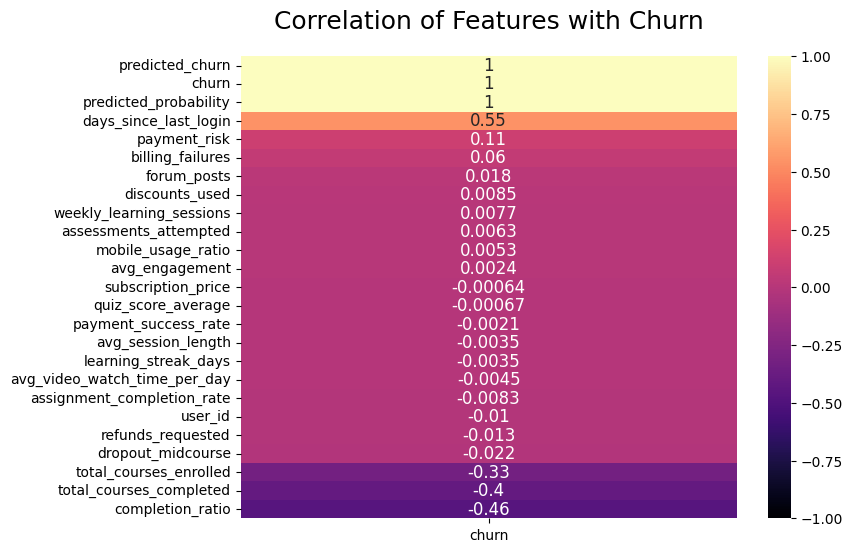

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)['churn'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="magma",
    cbar=True,
    vmin=-1, vmax=1,
    annot_kws={"size": 12}
)
plt.title("Correlation of Features with Churn", fontsize=18, pad=20)
plt.show()
